# Audio and Voice Synthesis with AI (WaveNet, Jukebox)

## 📚 Learning Objectives

By completing this notebook, you will:
- Explain how neural audio synthesis works: WaveNet's sample-by-sample autoregression and
  Jukebox's audio-token language modeling
- Represent audio digitally — synthesize a vowel-like sound from sine waves and inspect its
  waveform and spectrum
- Compute why raw-audio generation is hard (samples-per-second arithmetic)
- Run a small autoregressive generator to feel the mechanism WaveNet applies to audio

## 🔗 Prerequisites

- ✅ Sequence models / autoregression (Unit 2)
- ✅ NumPy and matplotlib

---

This notebook covers practical activities from **Course 10, Unit 5**:
- Audio and voice synthesis using AI tools like WaveNet or Jukebox

---

## Introduction

**Audio and voice synthesis** models generate realistic speech and music. The full models are
far too large to train here — instead we build the two ideas they rest on: *audio as a sequence
of numbers* (hands-on below) and *autoregressive next-sample prediction* (toy model at the end).

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
print("✅ Libraries imported!")
print("\nAudio and Voice Synthesis")
print("=" * 60)

print("\nWaveNet:")
print("  - Text-to-speech")
print("  - High-quality audio")
print("  - Autoregressive model")
print("  - Realistic voice")

print("\nJukebox:")
print("  - Music generation")
print("  - Multiple genres")
print("  - Long sequences")
print("  - OpenAI model")

print("\nApplications:")
print("  - Text-to-speech")
print("  - Voice cloning")
print("  - Music composition")
print("  - Audio synthesis")

print("\n✅ Audio synthesis concepts understood!")

✅ Libraries imported!

Audio and Voice Synthesis

WaveNet:
  - Text-to-speech
  - High-quality audio
  - Autoregressive model
  - Realistic voice

Jukebox:
  - Music generation
  - Multiple genres
  - Long sequences
  - OpenAI model

Applications:
  - Text-to-speech
  - Voice cloning
  - Music composition
  - Audio synthesis

✅ Audio synthesis concepts understood!


## Hands-On: What Audio Looks Like to a Neural Network

Sound is a **pressure wave sampled thousands of times per second** — to a model, just a very long
sequence of numbers. Human speech gets its character from **formants** (resonant frequency peaks
of the vocal tract). Below we synthesize a vowel-like tone from three sine waves at real formant
frequencies for the vowel "ah", plot what the network would "see", and compute the arithmetic
that makes raw-audio generation so much harder than text generation.

One second of audio at 16,000 Hz = 16,000 numbers — press play:


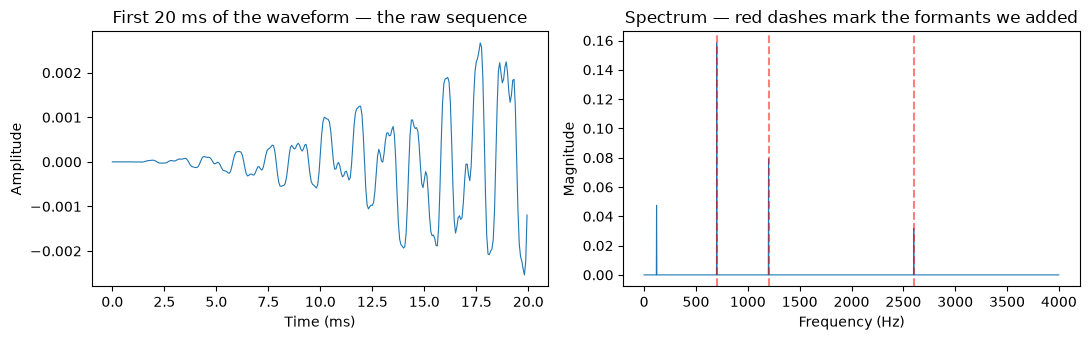

10 seconds of TEXT  ≈    150 tokens for a character model
10 seconds of AUDIO = 160,000 samples for WaveNet at 16 kHz
→ 1,066x more predictions for the same duration —
  this is why WaveNet needed dilated convolutions, and why later systems
  (Jukebox, modern TTS) first COMPRESS audio into coarser tokens, then model those.


In [2]:
# Synthesize a vowel-like sound from formant sine waves; show waveform + spectrum;
# compute the sequence-length arithmetic that makes audio generation hard.
# WHY: before understanding WaveNet, you need to see audio as the (huge) number sequence it is.
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

SR = 16000                              # 16 kHz — the sample rate WaveNet used for speech
DUR = 1.0                               # one second of audio
t = np.arange(int(SR * DUR)) / SR

# ── Build an "ah"-like vowel: fundamental + three formants (typical adult values) ──
f0 = 120                                 # fundamental (vocal-fold vibration, male-ish pitch)
formants = [(700, 1.0), (1200, 0.5), (2600, 0.2)]   # (frequency Hz, relative amplitude)
wave = 0.3 * np.sin(2 * np.pi * f0 * t)              # the pitch buzz
for freq, amp in formants:
    wave += amp * np.sin(2 * np.pi * freq * t)       # add each resonance
wave *= np.hanning(len(wave))                        # fade in/out to avoid clicks
wave /= np.abs(wave).max()                           # normalize to [-1, 1]

print(f"One second of audio at {SR:,} Hz = {len(wave):,} numbers — press play:")
display(Audio(wave, rate=SR))

# ── Plot: 20 ms of waveform (what the model predicts) + frequency spectrum ─
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(t[:320] * 1000, wave[:320], lw=0.8)
axes[0].set_xlabel("Time (ms)"); axes[0].set_ylabel("Amplitude")
axes[0].set_title("First 20 ms of the waveform — the raw sequence")
spectrum = np.abs(np.fft.rfft(wave)) / len(wave)
freqs = np.fft.rfftfreq(len(wave), 1 / SR)
axes[1].plot(freqs[freqs < 4000], spectrum[freqs < 4000], lw=0.8)
for f, _ in formants:
    axes[1].axvline(f, color='red', ls='--', alpha=0.5)
axes[1].set_xlabel("Frequency (Hz)"); axes[1].set_ylabel("Magnitude")
axes[1].set_title("Spectrum — red dashes mark the formants we added")
plt.tight_layout(); plt.show()

# ── The arithmetic that makes audio generation hard (computed, not asserted) ──
chars_10s   = 10 * 15                    # ~15 characters/second of read English text
samples_10s = 10 * SR
print(f"10 seconds of TEXT  ≈ {chars_10s:6,} tokens for a character model")
print(f"10 seconds of AUDIO = {samples_10s:6,} samples for WaveNet at {SR//1000} kHz")
print(f"→ {samples_10s // chars_10s:,}x more predictions for the same duration —")
print("  this is why WaveNet needed dilated convolutions, and why later systems")
print("  (Jukebox, modern TTS) first COMPRESS audio into coarser tokens, then model those.")

## 🌍 Worked Example — Autoregression, the Mechanism Inside WaveNet

WaveNet generates audio **one sample at a time**, each conditioned on the previous ones — the
same *autoregressive* recipe as a language model, just over 16,000-samples-per-second sequences
instead of characters. Jukebox does the same over compressed audio tokens.

Since a real WaveNet takes days of GPU time, we demonstrate the mechanism at trainable scale: a
**character-level model** predicting one token at a time. Every idea transfers — context window,
sampling, temperature — only the alphabet changes (characters here, audio samples in WaveNet).

In [3]:
# Train a small autoregressive model (over characters) to feel WaveNet's mechanism.
# WHY: next-token prediction is the shared engine — swap characters for audio samples
# and this becomes (a tiny) WaveNet.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np

torch.manual_seed(42)
# ── Training text ────────────────────────────────────────────────────────────
text = (
    "to be or not to be that is the question whether tis nobler in the mind "
    "to suffer the slings and arrows of outrageous fortune or to take arms against "
    "a sea of troubles and by opposing end them to die to sleep no more and by "
    "a sleep to say we end the heartache and the thousand natural shocks that "
    "flesh is heir to tis a consummation devoutly to be wished to die to sleep"
)

chars  = sorted(set(text))
c2i    = {c:i for i,c in enumerate(chars)}
i2c    = {i:c for c,i in c2i.items()}
VOCAB  = len(chars)
enc    = [c2i[c] for c in text]

SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(enc)-SEQ_LEN-1):
    X_list.append(enc[i:i+SEQ_LEN])
    y_list.append(enc[i+SEQ_LEN])
X_t = torch.tensor(X_list, dtype=torch.long)
y_t = torch.tensor(y_list, dtype=torch.long)

# ── LSTM Language Model ───────────────────────────────────────────────────
class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out,_ = self.lstm(self.embed(x))
        return self.fc(out[:,-1,:])

model   = CharLM()
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(200):
    model.train()
    perm = torch.randperm(len(X_t))[:256]  # mini-batch
    loss = loss_fn(model(X_t[perm]), y_t[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} — loss: {loss.item():.3f}")

# ── Text Generation (Greedy / Temperature Sampling) ──────────────────────
def generate(seed_str, steps=80, temperature=0.8):
    model.eval()
    chars_out = list(seed_str)
    ctx = [c2i.get(c, 0) for c in seed_str[-SEQ_LEN:]]
    for _ in range(steps):
        inp = torch.tensor([ctx[-SEQ_LEN:]]).long()
        with torch.no_grad():
            logits = model(inp)[0] / temperature
        probs = torch.softmax(logits, 0).numpy()
        next_c = np.random.choice(len(probs), p=probs)
        chars_out.append(i2c[next_c])
        ctx.append(next_c)
    return ''.join(chars_out)

print("\n── Generated Text ──────────────────────────────────────────────")
print(generate("to be or not", steps=100))
print("\nOne token at a time, each conditioned on the past — swap characters for")
print("audio samples and this loop is what WaveNet runs 16,000 times per second.")

Epoch 0 — loss: 3.169


Epoch 50 — loss: 1.298


Epoch 100 — loss: 0.053


Epoch 150 — loss: 0.011



── Generated Text ──────────────────────────────────────────────
to be or notek a suesar ofc the questio noutle o tor b eios trouble to suerows orouf to tureu sand to sufrea so 

One token at a time, each conditioned on the past — swap characters for
audio samples and this loop is what WaveNet runs 16,000 times per second.


## 📚 References & Further Reading

**Papers:**
- van den Oord et al. (2016) — [WaveNet: A Generative Model for Raw Audio](https://arxiv.org/abs/1609.03499)
- Dhariwal et al. (2020) — [Jukebox: A Generative Model for Music](https://arxiv.org/abs/2005.00341)
- Radford et al. (2019) — [GPT-2](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) *(the autoregressive recipe our toy demo shares)*

**Interactive:**
- [DeepMind's WaveNet post](https://deepmind.google/discover/blog/wavenet-a-generative-model-for-raw-audio/) — with audio samples
- [OpenAI Jukebox samples](https://openai.com/research/jukebox)

**State-of-the-Art:** ElevenLabs, Suno, and OpenAI's voice models build on these ideas with
audio-token language models plus diffusion/flow decoders.

## 📝 Summary

In this notebook, you:

- Synthesized a **vowel-like sound from formant sine waves** and inspected its waveform and
  spectrum — audio as the number sequence a model must predict
- **Computed** why raw audio is hard: ~1,000x more predictions per second than character-level
  text, which drove WaveNet's dilated convolutions and Jukebox's compress-then-model design
- Ran a small **autoregressive generator** to internalize the one-sample-at-a-time mechanism
- Learned the concepts behind **WaveNet** (autoregressive raw audio) and **Jukebox**
  (language modeling over compressed audio tokens)

**Further reading, not demonstrated here:** modern production TTS (ElevenLabs-class systems)
increasingly uses diffusion and flow-matching decoders on top of these ideas.